In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv("G:/Academics/4.1/capestone/TATASTEEL.csv")

df

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,TISCO,EQ,142.35,148.00,153.20,146.10,152.50,152.45,150.92,2003185,3.023164e+13,NaN,NaN,NaN
1,2000-01-04,TISCO,EQ,152.45,150.10,153.00,143.05,151.95,150.80,151.03,1555136,2.348785e+13,NaN,NaN,NaN
2,2000-01-05,TISCO,EQ,150.80,144.60,162.90,144.60,158.00,156.55,156.85,3840284,6.023364e+13,NaN,NaN,NaN
3,2000-01-06,TISCO,EQ,156.55,158.95,169.10,158.95,169.00,168.25,167.61,2560449,4.291530e+13,NaN,NaN,NaN
4,2000-01-07,TISCO,EQ,168.25,173.40,179.00,166.30,170.55,171.95,173.89,3641691,6.332459e+13,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5301,2021-04-26,TATASTEEL,EQ,925.60,935.00,956.00,930.05,942.50,940.75,942.98,21234858,2.002407e+15,274958.0,4584617.0,0.2159
5302,2021-04-27,TATASTEEL,EQ,940.75,948.30,983.00,944.30,982.00,977.75,965.43,24904515,2.404346e+15,331493.0,3575969.0,0.1436
5303,2021-04-28,TATASTEEL,EQ,977.75,985.00,986.00,962.00,971.00,971.40,972.08,20447968,1.987700e+15,255599.0,3550908.0,0.1737
5304,2021-04-29,TATASTEEL,EQ,971.40,983.00,1036.95,983.00,1035.00,1031.35,1015.76,44718647,4.542359e+15,554647.0,5539528.0,0.1239


In [36]:
#select only date and open

df = df[["Date","Open"]]

df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index("Date")
df

,Open
Date,
2000-01-03,148.00
2000-01-04,150.10
2000-01-05,144.60
2000-01-06,158.95
2000-01-07,173.40
...,...
2021-04-26,935.00
2021-04-27,948.30
2021-04-28,985.00


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5306 entries, 2000-01-03 to 2021-04-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    5306 non-null   float64
dtypes: float64(1)
memory usage: 82.9 KB


In [38]:
df.describe()

,Open
count,5306.000000
mean,404.253581
std,187.559958
min,66.000000
25%,275.600000
50%,403.000000
75%,525.000000
max,1024.000000


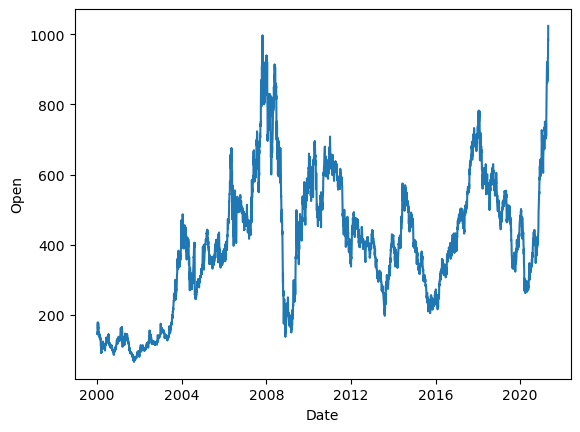

In [39]:
sns.lineplot(x =df.index,y=df['Open'])
plt.show()

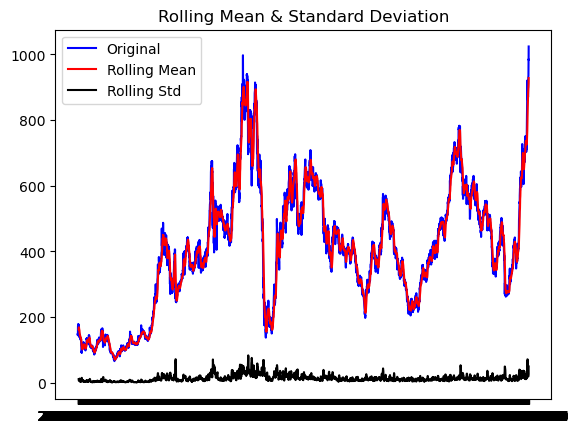

In [40]:
#Determing rolling statistics
rolmean = df['Open'].rolling(window=12).mean()
rolstd = df['Open'].rolling(window=12).std()

#Plot rolling statistics:
orig = plt.plot(df['Open'], color='blue', label='Original')
mean = plt.plot(rolmean, color='red', label='Rolling Mean')
std = plt.plot(rolstd, color='black', label = 'Rolling Std')
plt. title('Rolling Mean & Standard Deviation' )
plt.xticks(ticks=df.index)
plt. legend()
plt.show()

In [41]:
from statsmodels. tsa. stattools import adfuller
adfuller_result = adfuller(df['Open' ])
adfuller_result

#p-value is greater than 0.05  so accept null hypothesis
#h0 : data is not stationary
#h1 : data is stationary

(-1.7085482799699963,
 0.4267136150294156,
 27,
 5278,
 {'1%': -3.431589576207423,
  '5%': -2.8620877649933933,
  '10%': -2.5670615748785846},
 42242.45301254853)

In [42]:
# apply differencing
diff = df['Open' ]- df ['Open' ]. shift(19)

diff.dropna(inplace=True)

# check whether the data is stationary or not after applying differencing
adfuller_result = adfuller(diff)
print('p-value of adf test:', adfuller_result[1])


#data is stationary for shift=2

p-value of adf test: 1.8299404353803833e-17


In [43]:
len(diff)

5287

In [44]:
#splitting the data into 80% train and 20% test

y_train = diff[:3700]
y_test = diff[3701: ]

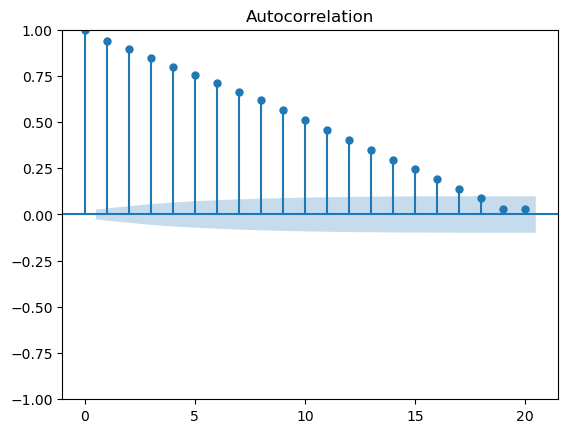

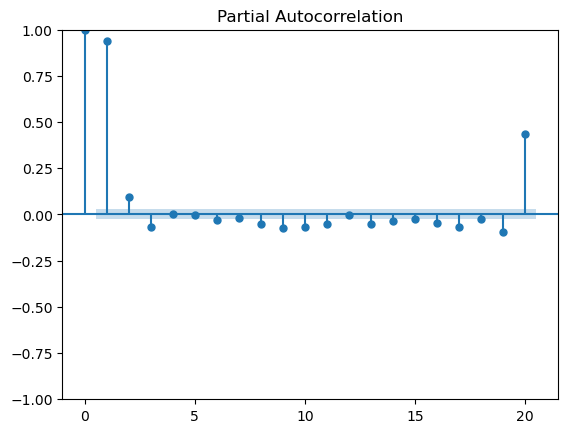

In [45]:
from statsmodels. tsa. stattools import acf, pacf
import statsmodels. api as sm
fig = sm.graphics.tsa.plot_acf(diff,lags=20)
fig = sm.graphics.tsa.plot_pacf(diff,lags=20)

In [46]:
import warnings
warnings.filterwarnings('ignore')

In [47]:
#ModelLing
from statsmodels. tsa. arima.model import ARIMA
model = ARIMA(diff, order=(1,2,1))
ARIMA = model.fit()

#Prediction
ypred_test = ARIMA. predict(start=y_test.index[0], end=y_test. index[-1])
ypred_train = ARIMA.predict(start=y_train.index[0], end=y_train.index[-1])

#Evaluation
from sklearn.metrics import r2_score
print("Train R2 of ARIMA Model:",r2_score(ypred_train,y_train))
print("Test R2 of ARIMA Model:",r2_score(ypred_test,y_test))

Train R2 of ARIMA Model: 0.8781161357933546
Test R2 of ARIMA Model: 0.9063543575908068


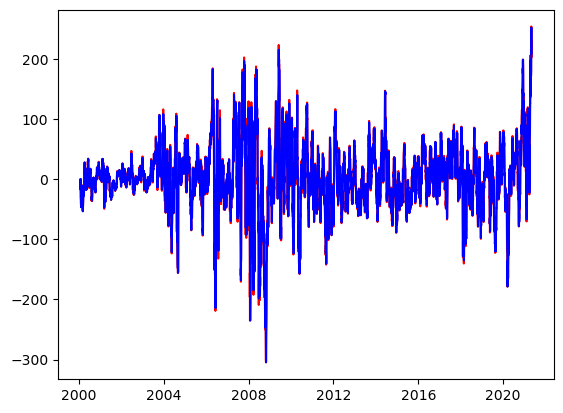

In [62]:

pred = ARIMA.predict(start='2000-01-31', end='2021-04-30')

plt.plot(diff,color='red')
plt.plot(pred,color='blue')

plt.show()

SARIMAX

In [15]:
##ModeLLing
from statsmodels. tsa. statespace. sarimax import SARIMAX
model = SARIMAX(diff,seasonal_order=(1,0,1,12))
SARIMAX = model.fit()

#Prediction
ypred_train = SARIMAX.predict(start=y_train.index[0], end=y_train.index[-1])
ypred_test = SARIMAX.predict(start=y_test.index[0], end=y_test. index[-1])

#Evaluation
from sklearn.metrics import r2_score
print("Train R2 of SARIMAX model:",r2_score(ypred_train,y_train))
print("Test R2 of SARIMAX model:",r2_score(ypred_test,y_test))

Train R2 of SARIMAX model: 0.8671489561883158
Test R2 of SARIMAX model: 0.8982022051019086


ConversionError: Failed to convert value(s) to axis units: array(['2000-01-31T00:00:00.000000000', '2000-02-01T00:00:00.000000000',
       '2000-02-02T00:00:00.000000000', ...,
       '2021-04-28T00:00:00.000000000', '2021-04-29T00:00:00.000000000',
       '2021-04-30T00:00:00.000000000'], dtype='datetime64[ns]')

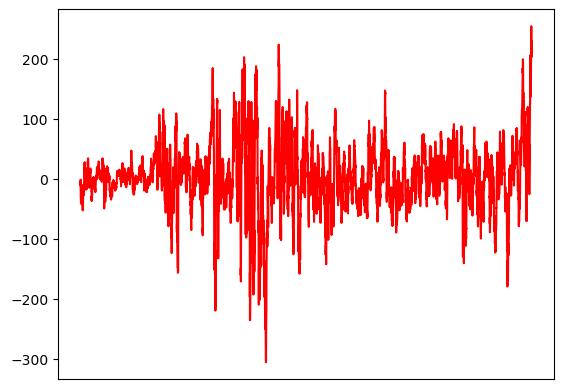

In [64]:

pred = SARIMAX.predict(start='2000-01-31', end='2021-04-30')

plt.plot(diff,color='red')
plt.plot(pred,color='blue')

plt.show()

In [16]:
# from statsmodels.tsa.api import VAR

# var_model = VAR(y_train)
# var_result = var_model.fit(maxlags=20, ic='aic')  
# lag_order = var_result.k_ar
# forecast_input = train.values[-lag_order:]
# forecast = var_result.forecast(y=forecast_input, steps=len(y_test))

# # Convert forecast back to DataFrame
# forecast_df = pd.DataFrame(forecast, index=test.index, columns=train.columns)

# # Evaluate (assuming one variable of interest)
# mse = mean_squared_error(y_test, forecast)
# print(f'VAR MSE: {mse}')
